# Open-hole processing: from waveform to log curve

*The core `fwap` workflow — Parts 1 and 2 of Mari, Coppens, Gavin & Wicquart
(1994) — run end to end on synthetic data with known answers.*

A full-waveform acoustic tool fires a source and records the wavetrain at an
array of receivers. Several modes arrive on the same record: the compressional
head wave first, then shear, then the slow, high-amplitude Stoneley tube wave.
The processing job is to separate them, pick each one's slowness, and turn a
depth series of picks into log curves.

This notebook does exactly that:

1. **Synthesize** a monopole gather with known mode velocities.
2. **Slowness-time coherence (STC)** — the semblance surface every pick comes from.
3. **Pick** P / S / Stoneley and check them against the truth we planted.
4. **Separate** the modes with an f-k and a tau-p filter.
5. **Track across depth** and emit LAS-ready log curves.

Everything is NumPy/SciPy — no ML, no PyTorch. For the machine-learning layer
built on top of this physics, see the
[`sonic_ml` tutorial](sonic_ml_tutorial.ipynb).

## Setup

In [1]:
import matplotlib.pyplot as plt
import numpy as np

import fwap
from fwap import (
    ArrayGeometry,
    fk_filter,
    monopole_formation_modes,
    pick_modes,
    quality_control_picks,
    stc,
    synthesize_gather,
    tau_p_filter,
    track_modes,
    track_to_log_curves,
)

US_PER_FT = 1.0e6 * 0.3048  # slowness s/m -> us/ft
print("fwap", fwap.__version__)

fwap 0.4.0


## 1. A synthetic monopole gather

`ArrayGeometry` describes the tool: how many receivers, how far the first one
sits from the transmitter, the receiver spacing, and the sampling interval.
`monopole_formation_modes` returns the P, S and Stoneley arrivals for a chosen
formation, and `synthesize_gather` sums them into a multichannel record.

Because we *chose* the velocities, we know the right answer — which is what
makes this a tutorial rather than a demo.

In [2]:
geom = ArrayGeometry(n_rec=8, tr_offset=3.0, dr=0.1524, dt=1.0e-5, n_samples=2048)

VP, VS, V_ST = 4000.0, 2300.0, 1400.0
modes = monopole_formation_modes(vp=VP, vs=VS, v_stoneley=V_ST)
data = synthesize_gather(geom, modes, noise=0.02, seed=0)

print(f"geometry : {geom.n_rec} receivers, dr = {geom.dr:.4f} m, dt = {geom.dt*1e6:.0f} us")
print(f"offsets  : {geom.offsets[0]:.2f} - {geom.offsets[-1]:.2f} m")
print(f"gather   : {data.shape}  (receivers, time samples)")
print("\nplanted truth:")
for name, v in [("P", VP), ("S", VS), ("Stoneley", V_ST)]:
    print(f"  {name:<9} {v:6.0f} m/s  =  {US_PER_FT / v:6.1f} us/ft")

geometry : 8 receivers, dr = 0.1524 m, dt = 10 us
offsets  : 3.00 - 4.07 m
gather   : (8, 2048)  (receivers, time samples)

planted truth:
  P           4000 m/s  =    76.2 us/ft
  S           2300 m/s  =   132.5 us/ft
  Stoneley    1400 m/s  =   217.7 us/ft


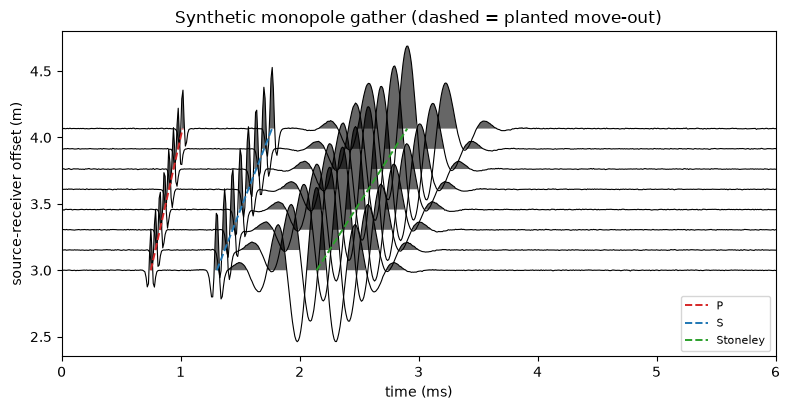

In [3]:
t_ms = np.arange(geom.n_samples) * geom.dt * 1e3
fig, ax = plt.subplots(figsize=(8, 4.2))
scale = 1.6 * np.max(np.abs(data))
for i in range(geom.n_rec):
    trace = data[i] / scale + geom.offsets[i]
    ax.plot(t_ms, trace, "k-", lw=0.8)
    ax.fill_between(t_ms, geom.offsets[i], trace, where=trace > geom.offsets[i],
                    color="k", alpha=0.6, lw=0)
for name, v, color in [("P", VP, "tab:red"), ("S", VS, "tab:blue"),
                       ("Stoneley", V_ST, "tab:green")]:
    ax.plot(geom.offsets / v * 1e3, geom.offsets, "--", color=color, lw=1.4, label=name)
ax.set_xlim(0, 6)
ax.set_xlabel("time (ms)")
ax.set_ylabel("source-receiver offset (m)")
ax.set_title("Synthetic monopole gather (dashed = planted move-out)")
ax.legend(fontsize=8, loc="lower right")
plt.tight_layout()
plt.show()

## 2. Slowness-time coherence

STC is the workhorse of Part 1. It sweeps a window over the record and, for each
(arrival time, trial slowness) pair, measures how coherently the traces stack
when moved out at that slowness. A real arrival shows up as a bright spot.

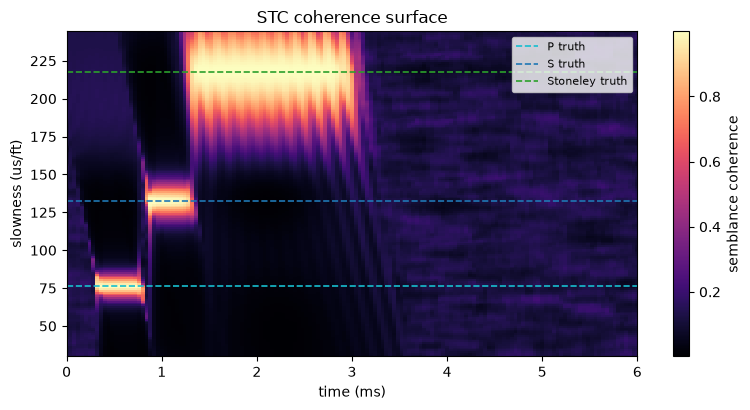

In [4]:
surface = stc(data, dt=geom.dt, offsets=geom.offsets,
              slowness_range=(1.0e-4, 8.0e-4), n_slowness=181,
              window_length=4.0e-4)

fig, ax = plt.subplots(figsize=(8, 4.2))
# coherence is (slowness, time) -- already (Y, X) for pcolormesh.
# Decimate along time purely to keep the stored figure small.
step = 4
mesh = ax.pcolormesh(surface.time[::step] * 1e3, surface.slowness * US_PER_FT,
                     np.nan_to_num(surface.coherence)[:, ::step], shading="auto",
                     cmap="magma")
for name, v, color in [("P", VP, "tab:cyan"), ("S", VS, "tab:blue"),
                       ("Stoneley", V_ST, "tab:green")]:
    ax.axhline(US_PER_FT / v, color=color, ls="--", lw=1.2, label=f"{name} truth")
fig.colorbar(mesh, ax=ax, label="semblance coherence")
ax.set_xlim(0, 6)
ax.set_xlabel("time (ms)")
ax.set_ylabel("slowness (us/ft)")
ax.set_title("STC coherence surface")
ax.legend(fontsize=8, loc="upper right")
plt.tight_layout()
plt.show()

## 3. Picking

`pick_modes` turns the coherence surface into named picks. It uses per-mode
slowness priors plus the canonical time ordering (P before S before Stoneley),
so it returns a labelled dictionary rather than an unordered list of maxima.

Time ordering alone is not enough, because two modes can satisfy it by landing
on the *same* peak — which is what happened at 143 of 400 depths of a real
Schlumberger log. `pick_modes` therefore also refuses to give one arrival two
labels; pass `resolve_mode_collisions=False` to see the old behaviour.

Each `ModePick` carries slowness, arrival time, coherence **and** amplitude —
the amplitude and coherence logs are the other half of the book's Workflow-1
deliverable, so they come straight off the picker.

In [5]:
picks = pick_modes(surface)
truth = {"P": VP, "S": VS, "Stoneley": V_ST}

print(f"{'mode':<12}{'picked':>10}{'truth':>10}{'error':>9}{'coh':>7}{'amp':>8}")
for name, pick in picks.items():
    got = pick.slowness * US_PER_FT
    if name in truth:
        want = US_PER_FT / truth[name]
        print(f"{name:<12}{got:>9.1f}{want:>10.1f}{got - want:>+9.1f}"
              f"{pick.coherence:>7.2f}{pick.amplitude:>8.3f}   us/ft")
    else:
        print(f"{name:<12}{got:>9.1f}{'-':>10}{'-':>9}"
              f"{pick.coherence:>7.2f}{pick.amplitude:>8.3f}   us/ft")

qc = quality_control_picks(picks, depth=1000.0)
print(f"\nQC flagged: {qc.flagged}" + (f"  reasons: {qc.reasons}" if qc.flagged else ""))

mode            picked     truth    error    coh     amp
P                76.7      76.2     +0.5   1.00   0.197   us/ft
S               132.4     132.5     -0.1   1.00   0.365   us/ft
PseudoRayleigh    132.4         -        -   1.00   0.365   us/ft
Stoneley        217.8     217.7     +0.0   1.00   1.370   us/ft

QC flagged: False


## 4. Wave separation

Part 2 is about pulling one mode out of the record. Two complementary filters:

* **f-k** works in the frequency-wavenumber plane. Resolving a slowness band
  there needs enough receivers to resolve *wavenumber* — and a typical sonic
  array has only eight.
* **tau-p** (slant stack) works in the intercept-time / slowness plane, using
  the offsets directly, so it does not depend on wavenumber resolution.

We keep the Stoneley slowness band and ask how much the fast-arrival energy
falls **relative to** the Stoneley energy. Only that ratio is comparable
between the two: the slant-stack adjoint is not unitary, so the filters have
different absolute gains and comparing raw energies across them is meaningless.

record              fast/Stoneley energy    vs raw
raw                               0.1449      1.0x
f-k filtered                      0.1487      1.0x
tau-p filtered                    0.0513      2.8x


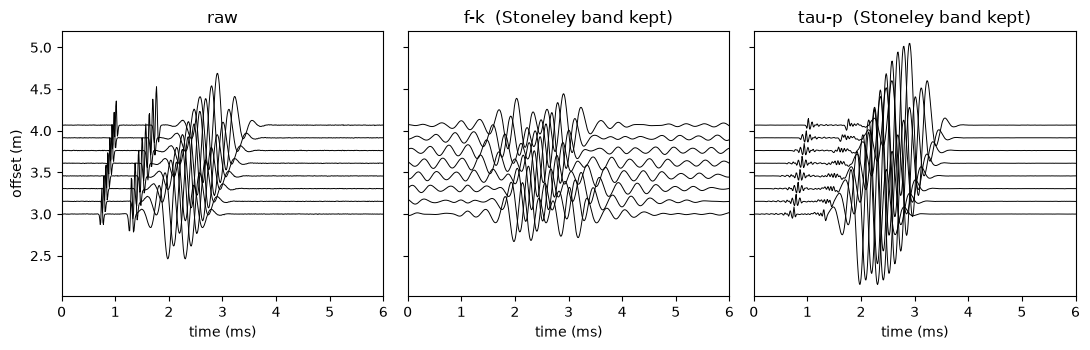

In [6]:
st_slow = 1.0 / V_ST
band = (st_slow * 0.85, st_slow * 1.15)

fk_only = fk_filter(data, dt=geom.dt, dx=geom.dr, slow_min=band[0], slow_max=band[1])
taup_only = tau_p_filter(data, dt=geom.dt, offsets=geom.offsets,
                         slow_min=band[0], slow_max=band[1])

early = slice(0, int(2.0e-3 / geom.dt))   # P/S window
late = slice(int(2.0e-3 / geom.dt), None)  # Stoneley window


def fast_to_stoneley(x):
    # Energy in the P/S window divided by energy in the Stoneley window.
    return float(np.sum(x[:, early] ** 2) / np.sum(x[:, late] ** 2))


raw_ratio = fast_to_stoneley(data)
print(f"{'record':<18}{'fast/Stoneley energy':>22}{'vs raw':>10}")
for label, arr in [("raw", data), ("f-k filtered", fk_only), ("tau-p filtered", taup_only)]:
    r = fast_to_stoneley(arr)
    print(f"{label:<18}{r:>22.4f}{raw_ratio / r:>9.1f}x")

fig, axes = plt.subplots(1, 3, figsize=(11, 3.6), sharey=True)
for ax, (label, arr) in zip(axes, [("raw", data), ("f-k", fk_only), ("tau-p", taup_only)]):
    s = 1.6 * np.max(np.abs(data))
    for i in range(geom.n_rec):
        ax.plot(t_ms, arr[i] / s + geom.offsets[i], "k-", lw=0.7)
    ax.set_xlim(0, 6)
    ax.set_title(f"{label}  (Stoneley band kept)" if label != "raw" else "raw")
    ax.set_xlabel("time (ms)")
axes[0].set_ylabel("offset (m)")
plt.tight_layout()
plt.show()

The tau-p filter suppresses the fast arrivals by roughly a factor of three
relative to the Stoneley; the f-k filter barely moves the ratio at all.

That is not a bug, it is aperture. With eight receivers spanning about a metre,
the f-k transform has almost no wavenumber resolution, so a slowness band in
(f, k) is a very blunt instrument. The tau-p transform stacks along the actual
offsets and does not need that resolution, which is exactly why the book leans
on slant-stack methods for array sonic records. On a densely-sampled surface
seismic line the comparison would come out the other way round.

## 5. A depth series becomes a log

One gather gives one depth. Repeat down a well, and `track_modes` links the
picks across depth with a continuity constraint — so a single noisy frame cannot
throw the log off — and `track_to_log_curves` emits the `{mnemonic: array}` dict
the LAS / DLIS writers consume directly.

We fake a simple two-layer well: a slower interval in the middle.

log curves produced: ['AMPP', 'AMPPR', 'AMPS', 'AMPST', 'COHP', 'COHPR', 'COHS', 'COHST', 'DTP', 'DTPR', 'DTS', 'DTST', 'VPVS']


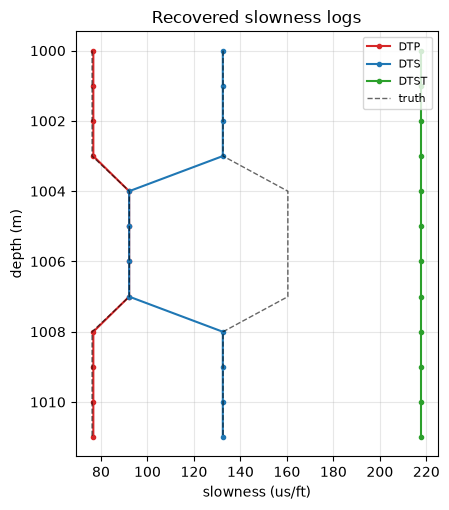

In [7]:
depths = np.arange(1000.0, 1012.0, 1.0)
vs_log = np.where((depths >= 1004) & (depths < 1008), 1900.0, 2300.0)
vp_log = vs_log * 1.74

results = []
for vp_d, vs_d in zip(vp_log, vs_log):
    d = synthesize_gather(
        geom, monopole_formation_modes(vp=vp_d, vs=vs_d, v_stoneley=V_ST),
        noise=0.03, seed=int(vs_d),
    )
    results.append(stc(d, dt=geom.dt, offsets=geom.offsets,
                       slowness_range=(1.0e-4, 8.0e-4), n_slowness=181,
                       window_length=4.0e-4))

track = track_modes(results, depths)
depth_arr, curves = track_to_log_curves(track)
print("log curves produced:", sorted(curves))

fig, ax = plt.subplots(figsize=(4.6, 5.2))
for mnem, color in [("DTP", "tab:red"), ("DTS", "tab:blue"), ("DTST", "tab:green")]:
    if mnem in curves:
        ax.plot(curves[mnem], depth_arr, "-o", ms=3, color=color, label=mnem)
ax.plot(US_PER_FT / vp_log, depths, "k--", lw=1, alpha=0.6, label="truth")
ax.plot(US_PER_FT / vs_log, depths, "k--", lw=1, alpha=0.6)
ax.invert_yaxis()
ax.set_xlabel("slowness (us/ft)")
ax.set_ylabel("depth (m)")
ax.set_title("Recovered slowness logs")
ax.grid(alpha=0.3)
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

## What we did

A raw multichannel waveform went in; DTP / DTS / DTST log curves came out, with
coherence and amplitude logs alongside, and the slow interval we planted at
1004–1008 m is visible in the recovered logs.

That is the book's Workflow 1 in full. Where to go next:

* **[Open-hole petrophysics](open_hole_petrophysics.ipynb)** — turn these logs
  into moduli, permeability and a safe mud-weight window.
* **[`sonic_ml` tutorial](sonic_ml_tutorial.ipynb)** — replace the classical
  pick-and-invert chain with a learned inverse, and see where that helps.
* `fwap.io` writes the curves to LAS, DLIS or SEG-Y.

Everything here is synthetic with planted answers. Real records bring
attenuation, tool effects, borehole rugosity, and modes that overlap far more
than these do — the QC flags and coherence logs exist precisely because picks on
real data are not always trustworthy.